# Final Visualizations

## Generate Viz

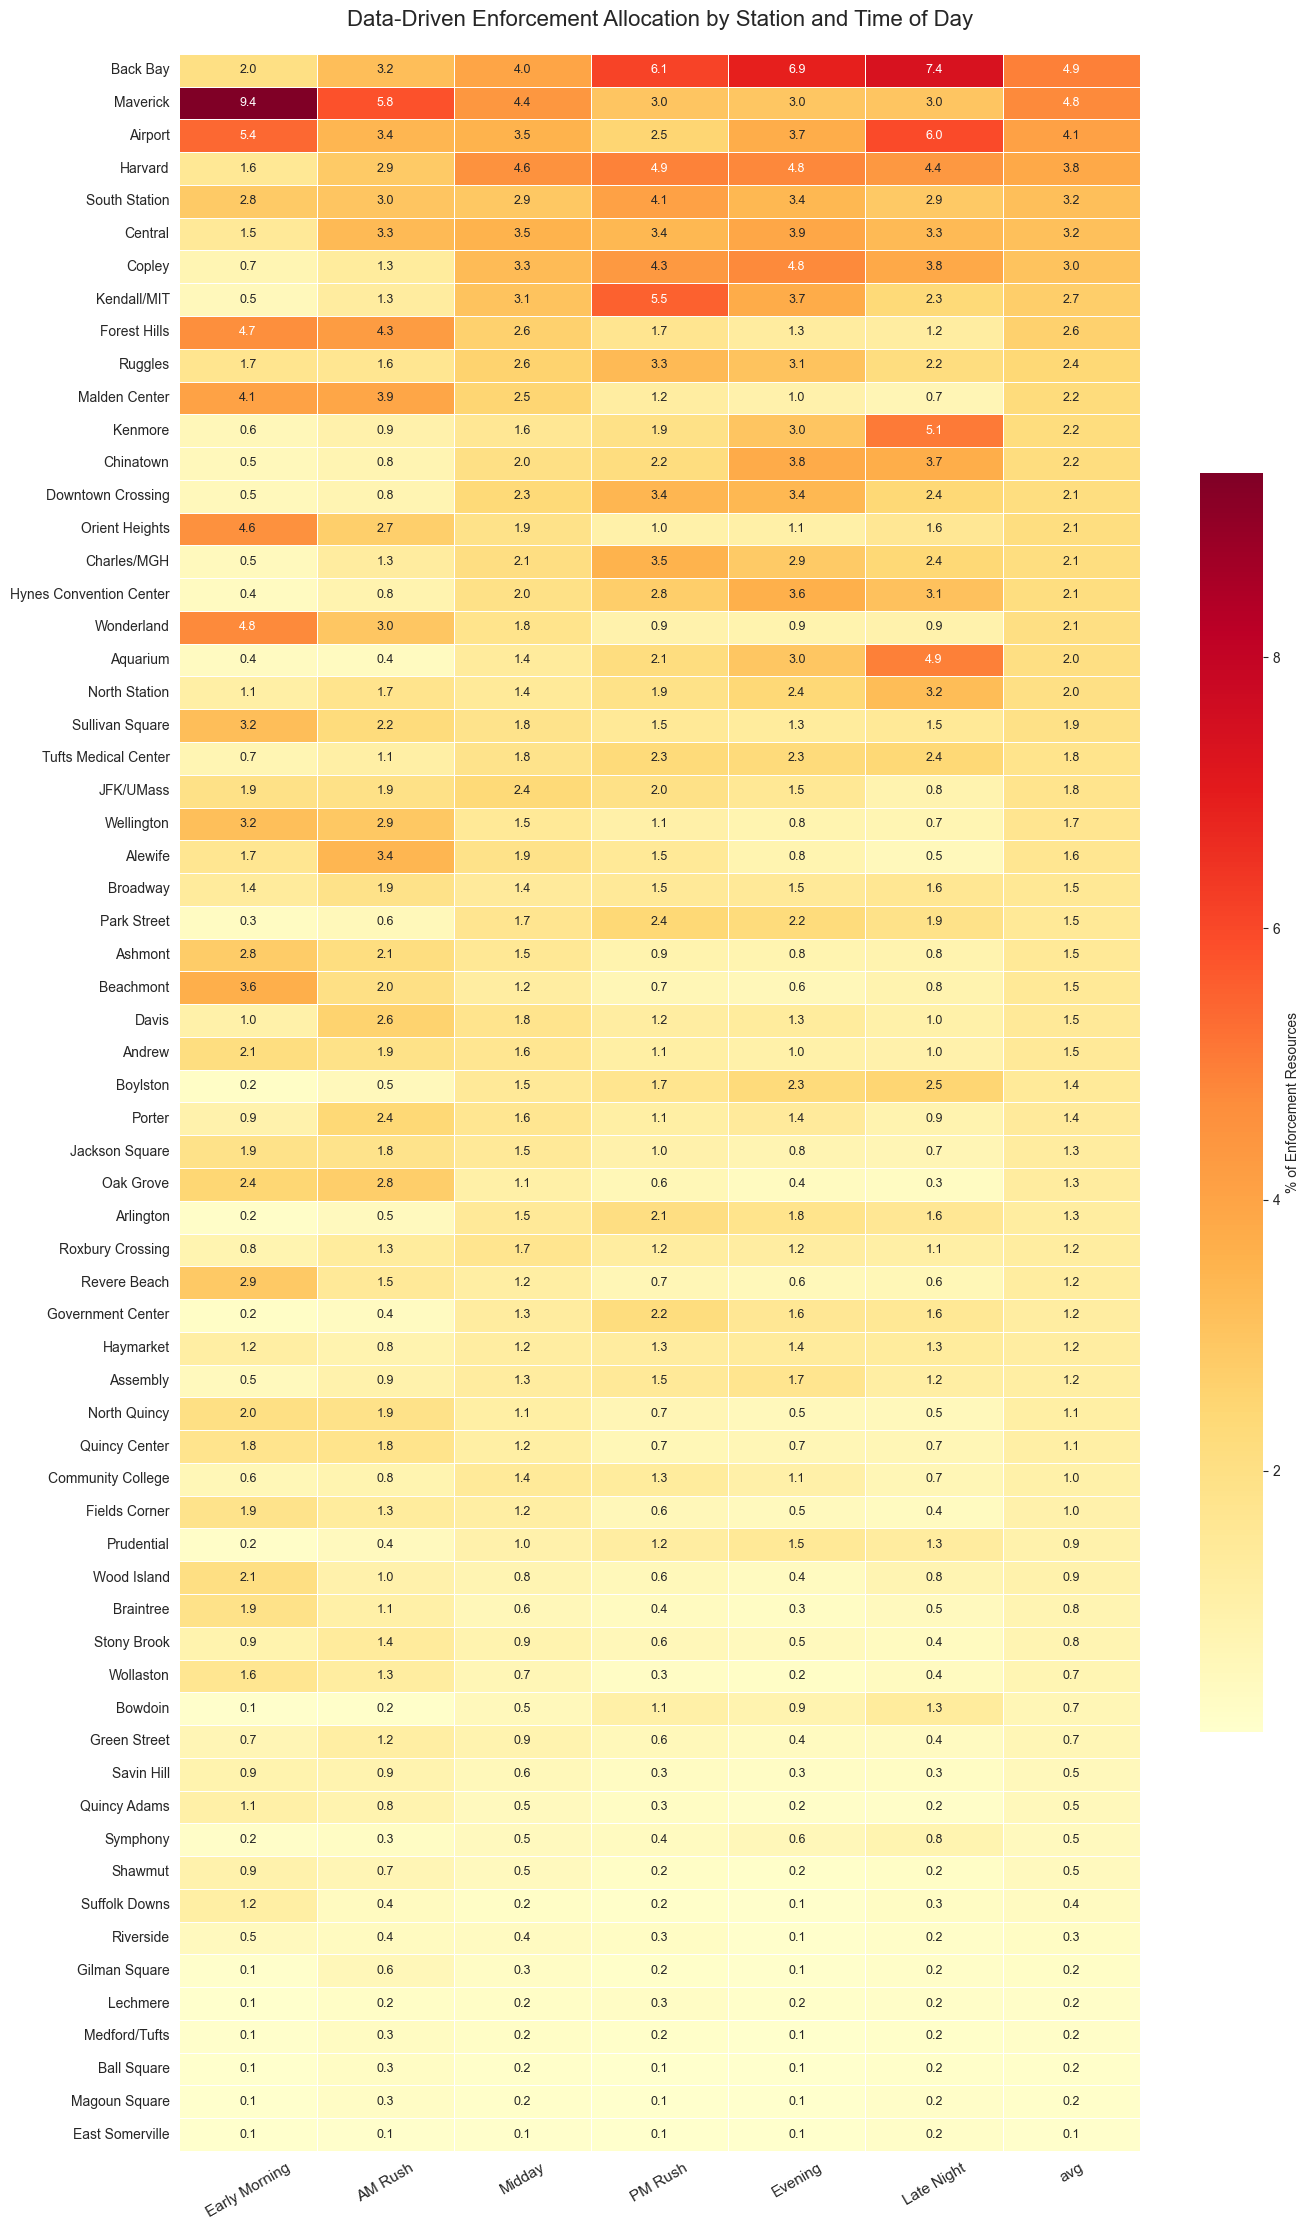

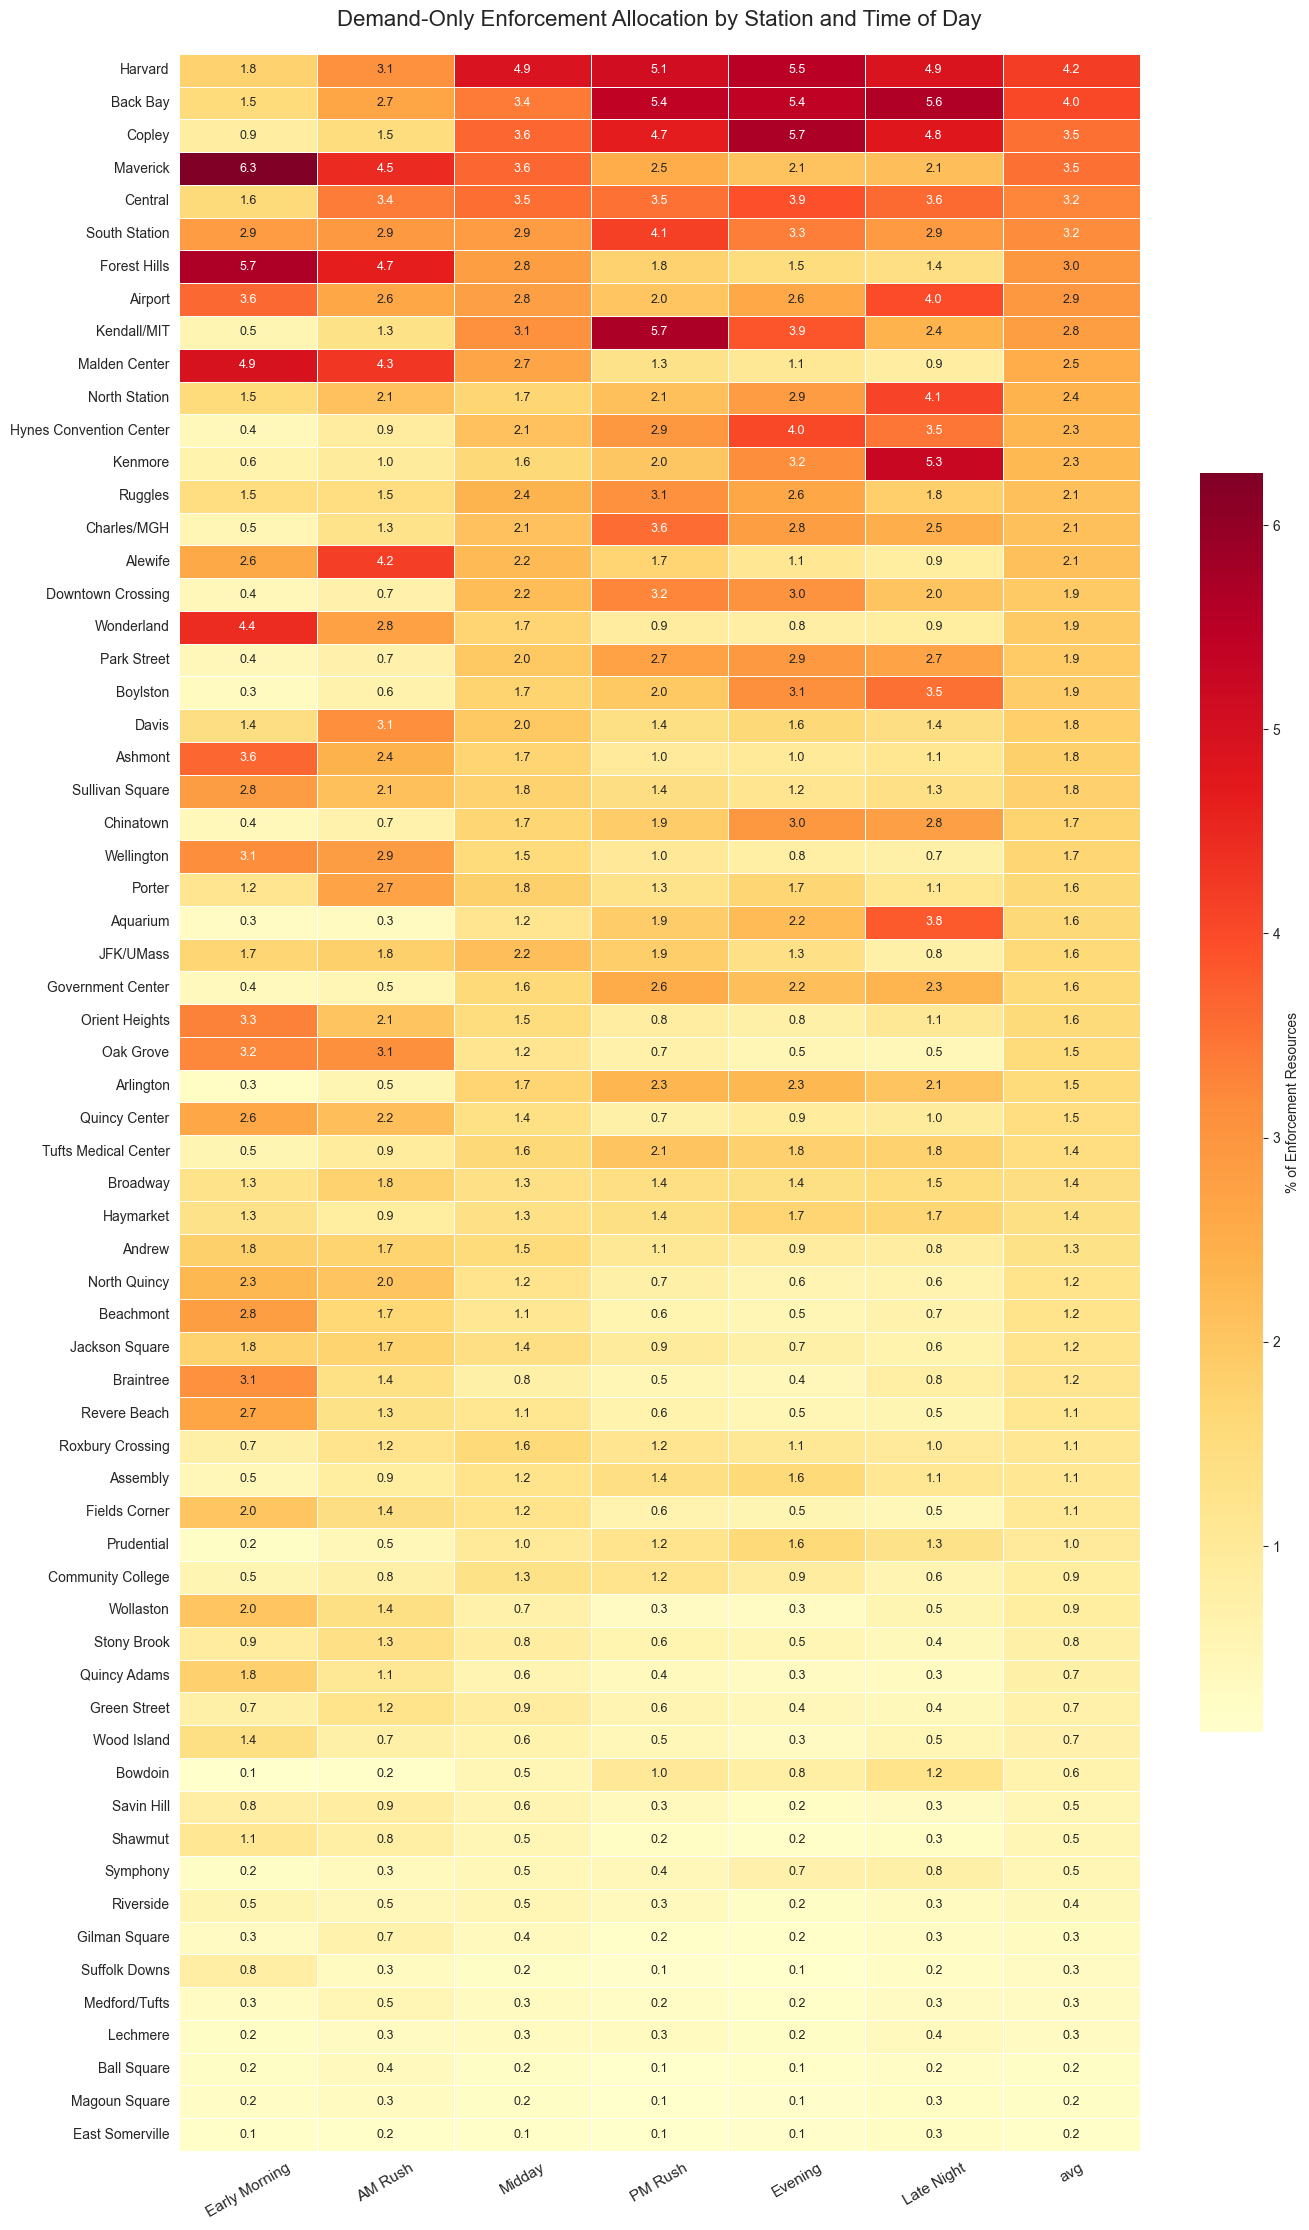

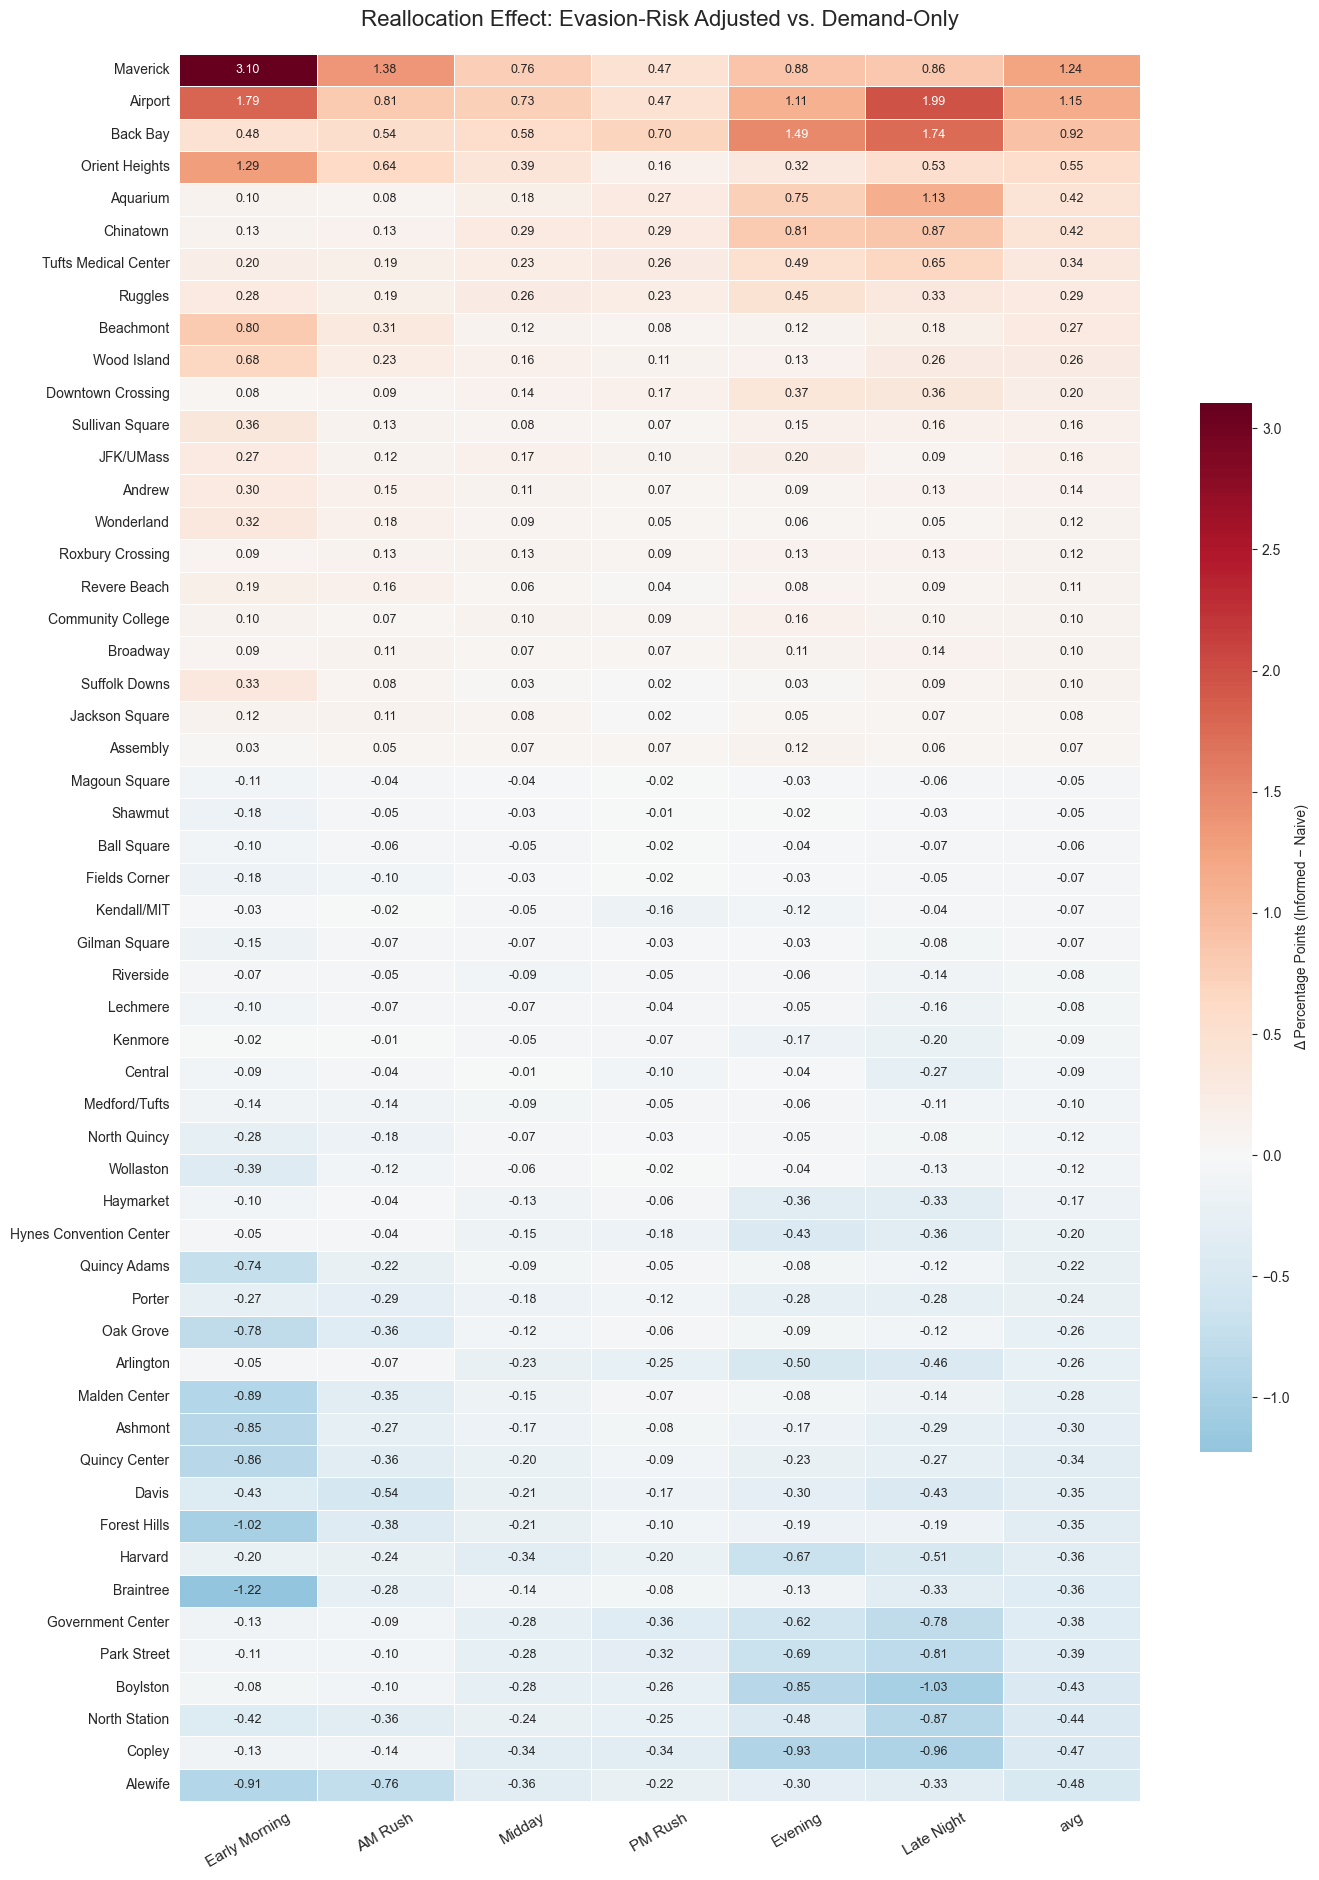

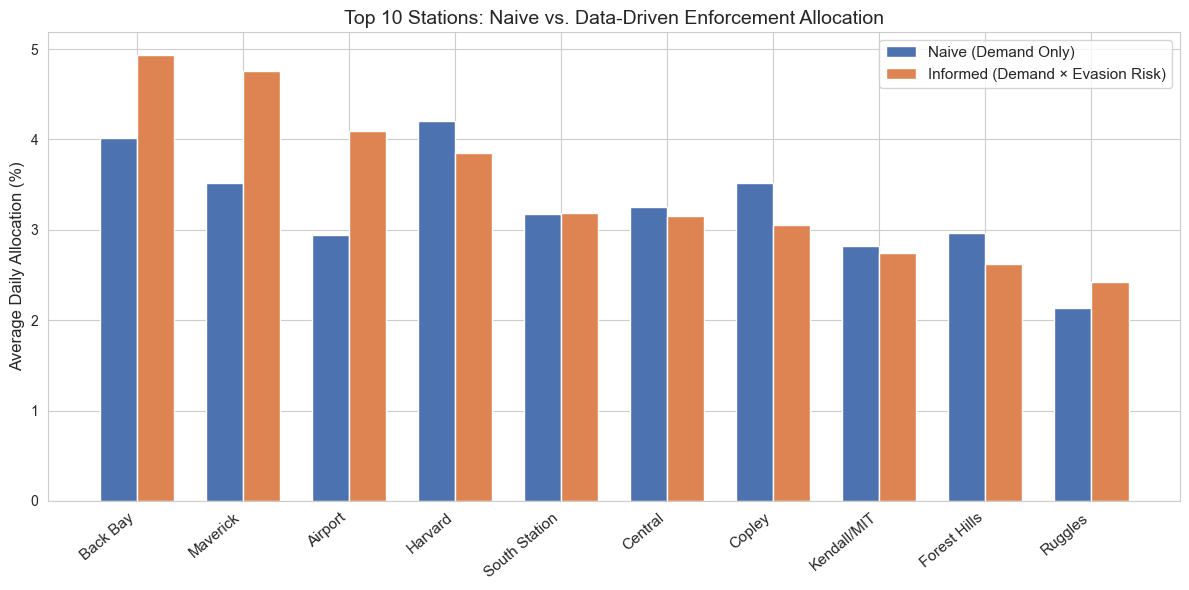

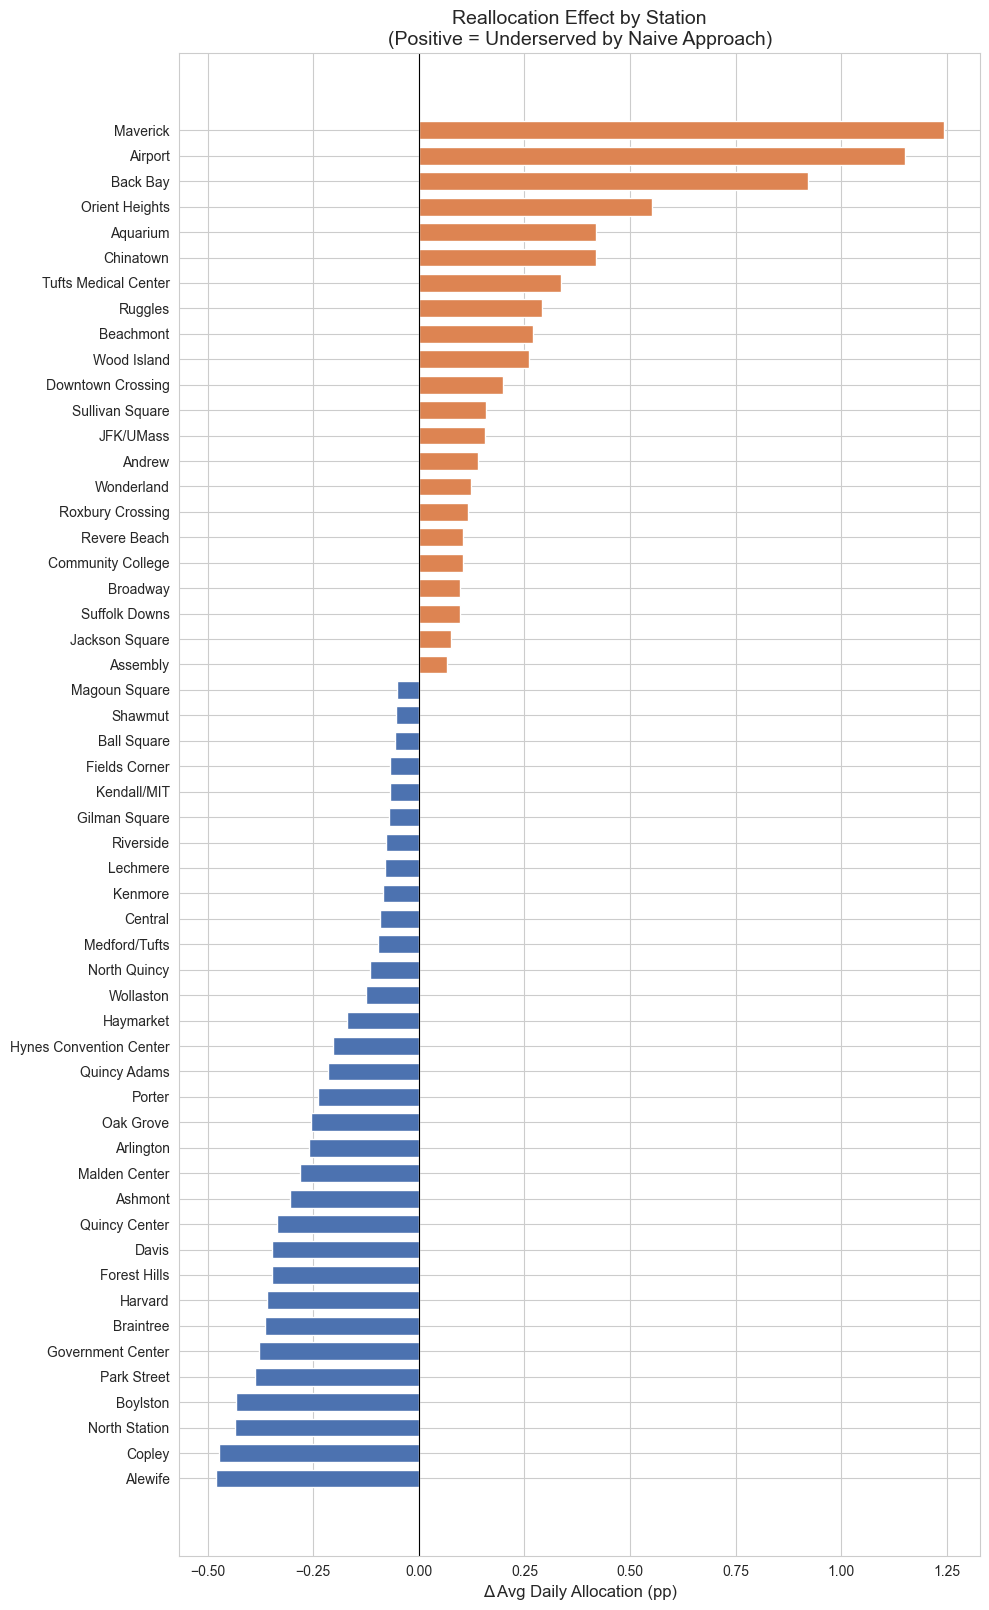

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

naive_pct = pd.read_csv("data/output_data/naive_allocation.csv", index_col=0) * 100
informed_pct = pd.read_csv("data/output_data/informed_allocation.csv", index_col=0) * 100
delta_pct = pd.read_csv("data/output_data/allocation_delta.csv", index_col=0) * 100

naive_pct["avg"] = naive_pct.mean(axis=1)
informed_pct["avg"] = informed_pct.mean(axis=1)
delta_pct["avg"] = delta_pct.mean(axis=1)

# Filter near-zero
delta_pct = delta_pct[delta_pct["avg"].abs() > 0.05]
informed_pct = informed_pct[informed_pct["avg"] > 0.05]
naive_pct = naive_pct[naive_pct["avg"] > 0.05]

sns.set_style("whitegrid")
time_order = ["Early Morning", "AM Rush", "Midday", "PM Rush", "Evening", "Late Night", "avg"]

delta_pct["avg"] = delta_pct.mean(axis=1)
informed_pct["avg"] = informed_pct.mean(axis=1)
naive_pct["avg"] = naive_pct.mean(axis=1)

# Filter out zero-allocation stations
informed_pct = informed_pct[informed_pct["avg"] > 0]
naive_pct = naive_pct[naive_pct["avg"] > 0]
delta_pct = delta_pct[delta_pct["avg"].abs() > 0.01]  # drop near-zero deltas

# --- 1. Heatmap: Informed Allocation ---
fig, ax = plt.subplots(figsize=(14, max(8, len(informed_pct) * 0.35)))
sns.heatmap(
    informed_pct[time_order],
    cmap="YlOrRd",
    annot=True, fmt=".1f", annot_kws={"size": 9},
    linewidths=0.5,
    cbar_kws={"label": "% of Enforcement Resources", "shrink": 0.6},
    ax=ax
)
ax.set_title("Data-Driven Enforcement Allocation by Station and Time of Day", fontsize=16, pad=20)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=11, rotation=30)
plt.tight_layout()
plt.savefig("assets/heatmap_informed.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 2. Heatmap: Naive Allocation ---
fig, ax = plt.subplots(figsize=(14, max(8, len(naive_pct) * 0.35)))
sns.heatmap(
    naive_pct[time_order],
    cmap="YlOrRd",
    annot=True, fmt=".1f", annot_kws={"size": 9},
    linewidths=0.5,
    cbar_kws={"label": "% of Enforcement Resources", "shrink": 0.6},
    ax=ax
)
ax.set_title("Demand-Only Enforcement Allocation by Station and Time of Day", fontsize=16, pad=20)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=11, rotation=30)
plt.tight_layout()
plt.savefig("assets/heatmap_naive.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 2. Heatmap: Delta ---
fig, ax = plt.subplots(figsize=(14, max(8, len(delta_pct) * 0.35)))
sns.heatmap(
    delta_pct[time_order],
    cmap="RdBu_r", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    linewidths=0.5,
    cbar_kws={"label": "Δ Percentage Points (Informed − Naive)", "shrink": 0.6},
    ax=ax
)
ax.set_title("Reallocation Effect: Evasion-Risk Adjusted vs. Demand-Only", fontsize=16, pad=20)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=11, rotation=30)
plt.tight_layout()
plt.savefig("assets/heatmap_delta.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 3. Top 10 Stations: Naive vs Informed ---
top10_informed = informed_pct.nlargest(10, "avg")
top10_naive = naive_pct.loc[top10_informed.index, "avg"]

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top10_informed))
width = 0.35
ax.bar([i - width/2 for i in x], top10_naive, width, label="Naive (Demand Only)", color="#4C72B0")
ax.bar([i + width/2 for i in x], top10_informed["avg"], width, label="Informed (Demand × Evasion Risk)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(top10_informed.index, rotation=40, ha="right", fontsize=11)
ax.set_ylabel("Average Daily Allocation (%)", fontsize=12)
ax.set_title("Top 10 Stations: Naive vs. Data-Driven Enforcement Allocation", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("assets/bar_top10_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 4. Delta distribution ---
delta_sorted = delta_pct["avg"].sort_values()
delta_sorted = delta_sorted[delta_sorted.abs() > 0.01]  # drop near-zero

fig, ax = plt.subplots(figsize=(10, max(8, len(delta_sorted) * 0.3)))
colors = ["#DD8452" if v > 0 else "#4C72B0" for v in delta_sorted]
ax.barh(delta_sorted.index, delta_sorted, color=colors, height=0.7)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Δ Avg Daily Allocation (pp)", fontsize=12)
ax.set_title("Reallocation Effect by Station\n(Positive = Underserved by Naive Approach)", fontsize=14)
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.savefig("assets/bar_delta_all.png", dpi=300, bbox_inches="tight")
plt.show()